Linear Regression Model

Train size: (1370, 11)
Test size : (381, 11)
MSE        : 16614274.86
RMSE       : 4076.06
R²         : 0.5793
MAE        : 2802.68
Relative MSE : 0.4622
MAPE         : 414.39%


,Datum,Ist,Vorhersage
1370,2024-11-01,10986.60,9936.667950
1371,2024-11-02,15423.80,11544.524424
1372,2024-11-03,9494.20,10246.475061
1373,2024-11-04,3354.00,7595.752443
1374,2024-11-05,5702.30,5810.400684
1375,2024-11-06,4973.30,4673.723419
1376,2024-11-07,5935.70,6015.084360
1377,2024-11-08,9181.20,9949.308218
1378,2024-11-09,14831.50,11441.673838
1379,2024-11-10,12205.60,9057.955222


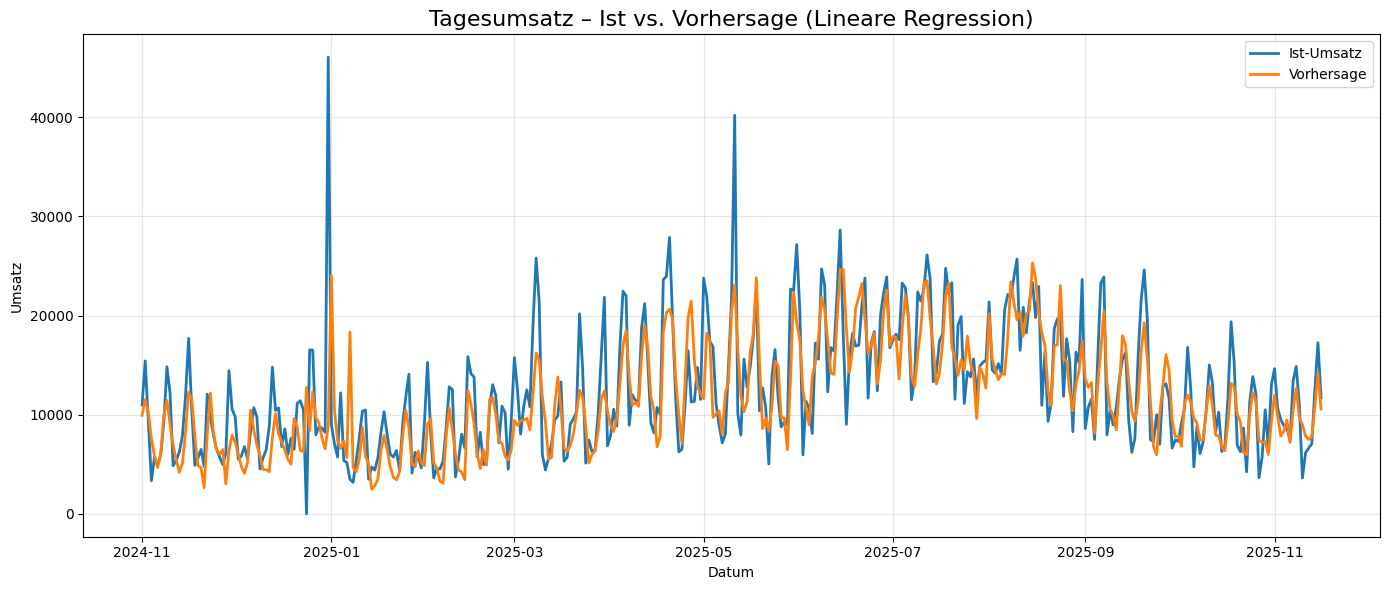

In [7]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# 1) Daten laden
df = pd.read_csv("data/dataset-merged-2.csv")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum")

# 1.1) Spalten entfernen, die Umsatzbestandteile sind (sonst data leakage)
df = df.drop(columns=["Terrasse", "Restaurant"], errors="ignore")

# 2) Zielvariable
target = "Tagesumsatz Restaurant"

# 3) Lag-Features
df["lag1"] = df[target].shift(1)
df["lag2"] = df[target].shift(2)
df["lag7"] = df[target].shift(7)
df["lag30"] = df[target].shift(30)

df = df.dropna().reset_index(drop=True)

# 4) Feature-Auswahl
num_cols = df.select_dtypes(include=["number"]).columns
cols_to_exclude = ["Tagesumsatz Restaurant", "Restaurant", "Terrasse"]
feature_cols = [c for c in num_cols if c not in cols_to_exclude]

X = df[feature_cols]
y = df[[target]]  # <-- wichtig: als DataFrame für StandardScaler

# 5) Zeitbasiertes Train/Test-Split (three weks into the new year)
split_date = pd.Timestamp("2024-11-01")
train_mask = df["Datum"] < split_date
test_mask  = df["Datum"] >= split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

# 6) Standardisierung von X und y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# 7) Modell trainieren
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled.ravel())

# 8) Vorhersagen (zunächst in normalisierter Form)
y_pred_scaled = model.predict(X_test_scaled)

# Rücktransformation in Originalskala
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
y_test_original = y_test.values.ravel()

# 9) Metriken berechnen
mse = mean_squared_error(y_test_original, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred)
mae = mean_absolute_error(y_test_original, y_pred)

# --- Relative MSE ----------------------------------------------------------
# naive baseline: yesterday's value (lag1)
y_naive = df.loc[test_mask, "lag1"].values  # already aligned for test set

# remove first sample (because lag1 has one-step shift)
mask_valid = ~pd.isna(y_naive)
y_true_rel = y_test_original[mask_valid]
y_pred_rel = y_pred[mask_valid]
y_naive_rel = y_naive[mask_valid]

mse_model = mean_squared_error(y_true_rel, y_pred_rel)
mse_naive = mean_squared_error(y_true_rel, y_naive_rel)
relative_MSE = mse_model / mse_naive

# --- MAPE ------------------------------------------------------------------
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # avoid division by zero
    mask = y_true != 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_value = mape(y_test_original, y_pred)

print(f"MSE        : {mse:.2f}")
print(f"RMSE       : {rmse:.2f}")
print(f"R²         : {r2:.4f}")
print(f"MAE        : {mae:.2f}")
print(f"Relative MSE : {relative_MSE:.4f}")
print(f"MAPE         : {mape_value:.2f}%")

# 10) Ergebnis-Tabelle
results = pd.DataFrame({
    "Datum": df.loc[test_mask, "Datum"],
    "Ist": y_test_original,
    "Vorhersage": y_pred
})

display(results.head(15))

# 11) Veranschaulichung als Plot
plt.figure(figsize=(14,6))
plt.plot(results["Datum"], results["Ist"], label="Ist-Umsatz", linewidth=2)
plt.plot(results["Datum"], results["Vorhersage"], label="Vorhersage", linewidth=2)

plt.title("Tagesumsatz – Ist vs. Vorhersage (Lineare Regression)", fontsize=16)
plt.xlabel("Datum")
plt.ylabel("Umsatz")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()